# Domain Analysis

Per-domain cultural-axis shifts (Family / Legal / Workplace / All) and entanglement ratios across Qwen, Llama, and Gemma. Extracted from `IVS_plot.ipynb`.


In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from factor_analyzer import FactorAnalyzer
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

import json

target_countries = ["Denmark", "Vietnam", "India", "Mexico"]
iv_qns = ["A008", "A165", "E018", "E025", "F063", "F118", "F120", "G006", "Y002", "Y003"]

X_axis_id = ["F063", "Y003", "F120", "G006", "E018"]  # Traditional vs Secular-rational
Y_axis_id = ["A008", "A165", "E025", "F118", "Y002"]  # Survival vs Self-expression

from ultis import load_probing_profile_data, answer_to_pivot

## Load default (baseline) probing profiles


In [2]:
from ultis import load_probing_profile_data, answer_to_pivot
probing_qwen_point = load_probing_profile_data('../qwen_prompt_steer_outputs_4/evaluation_results_default.json', model_name="Qwen3-4B-Instruct")
# probing_qwen_point2 = load_probing_profile_data('../outputs/qwen_probing_results/qwen3-4b-probing.json', model_name="Qwen3-4B-Instruct2")
probing_llama_point = load_probing_profile_data('../llama_prompt_steer_outputs/evaluation_results_default.json', model_name="Llama3.2-3B-Instruct")
probing_gemma_point = load_probing_profile_data('../gemma_prompt_steer_outputs/evaluation_results_default.json', model_name="Gemma3-4B-it")

probing_qwen_point['source_file'] = '../qwen_prompt_steer_outputs_4/evaluation_results_default.json'
probing_llama_point['source_file'] = '../llama_prompt_steer_outputs/evaluation_results_default.json'
probing_gemma_point['source_file'] = '../gemma_prompt_steer_outputs/evaluation_results_default.json'

probing_points_df = pd.DataFrame()
probing_points_df = pd.concat([probing_qwen_point, probing_llama_point, probing_gemma_point], ignore_index=True)
probing_points_df['color'] = ['red' , 'blue', 'green']
probing_points_df

# X_axis_id = ["F063",'Y003','F120','G006', 'E018'] # Tranditional vs Secular-rational
# Y_axis_id = ["A008", "A165", "E025", "F118", "Y002"] 

,domain,X,F063,Y003,F120,G006,E018,Y,A008,A165,E025,F118,Y002,RC1,RC2,country,source_file,color
0,All,4.992625,8.439901,1.432488,8.476071,3.620281,2.994382,3.870100,3.338209,1.475946,2.388735,9.692377,2.455231,2.058017,2.345887,Qwen3-4B-Instruct,../qwen_prompt_steer_outputs_4/evaluation_resu...,red
1,All,3.562527,6.075041,0.485462,6.328134,2.607159,2.316841,3.101616,2.633818,1.479228,2.173716,7.138553,2.082766,1.420904,1.367224,Llama3.2-3B-Instruct,../llama_prompt_steer_outputs/evaluation_resul...,blue
2,All,5.099484,8.112990,1.489097,9.361956,3.622428,2.910947,3.830192,3.241235,1.520032,2.540864,9.695205,2.153625,2.091993,2.418891,Gemma3-4B-it,../gemma_prompt_steer_outputs/evaluation_resul...,green


## Domain comparison utilities


In [3]:
import pandas as pd
import json

def compare_profile_on_axes(base_profile_path, target_profile_path, target_values='normalized_score'):
    # ... [Keep your existing data loading logic here] ...
	if type(base_profile_path) is str:
		with open(base_profile_path, 'r') as f:
			df_base = answer_to_pivot(json.load(f), split_by_domain=True, target_values=target_values)
	else:
		df_base = answer_to_pivot(base_profile_path, split_by_domain=True, target_values=target_values)
	if type(target_profile_path) is str:
		with open(target_profile_path, 'r') as f:
			df_target = answer_to_pivot(json.load(f), split_by_domain=True, target_values=target_values)
	else:
		df_target = answer_to_pivot(target_profile_path, split_by_domain=True, target_values=target_values)
    # Define Axis IDs from your WVS dimensions
	X_axis_id = ["F063", "Y003", "F120", "G006", "E018"] # Trad vs Secular
	Y_axis_id = ["A008", "A165", "E025", "F118", "Y002"] # Surv vs Self-Exp
	# print(df_base)
	df_base = df_base.set_index('domain')
	df_target = df_target.set_index('domain')
	df_diff = df_target - df_base

	results = pd.DataFrame(index=df_diff.index)

	# 1. Calculate the raw shift on both axes
	results['Shift_X'] = df_diff[X_axis_id].mean(axis=1) # Traditional -> Secular
	results['Shift_Y'] = df_diff[Y_axis_id].mean(axis=1) # Survival -> Self-Expression

	# 2. Calculate Entanglement Ratio (E)
	# If steering X: E = |Shift_Y| / |Shift_X|
	# If steering Y: E = |Shift_X| / |Shift_Y|
	# To handle general cases, we can look at the ratio of the minor shift to the major shift
	results['Entanglement_Ratio'] = results.apply(
		lambda row: min(abs(row['Shift_X']), abs(row['Shift_Y'])) / 
					max(abs(row['Shift_X']), abs(row['Shift_Y'])) 
					if max(abs(row['Shift_X']), abs(row['Shift_Y'])) != 0 else 0, 
		axis=1
	)

	# 3. Calculate Euclidean Magnitude
	results['Total_Magnitude'] = (results['Shift_X']**2 + results['Shift_Y']**2)**0.5

	return results, df_diff
base_profile = '../qwen_prompt_steer_outputs_4/evaluation_results_default.json' 
target_profile = '../qwen_steering_outputs_4/results_All_X_-0.2.json'

# Example Usage
comparison_results, differences = compare_profile_on_axes(base_profile, target_profile)
comparison_results

,Shift_X,Shift_Y,Entanglement_Ratio,Total_Magnitude
domain,,,,
Family,0.054912,0.086164,0.637290,0.102174
Legal,0.010769,0.053890,0.199825,0.054956
Workplace,0.077868,0.076370,0.980762,0.109068
All,0.047849,0.072142,0.663272,0.086568


In [4]:
def add_entanglement_ratios(probing_point_df, probing_vector_df):
    """
    Adds Entanglement_Ratio_<domain> columns to probing_vector_df.

    Calls compare_profile_on_axes for each row's (base, target) source_file pair,
    extracts Entanglement_Ratio per domain (All, Family, Legal, Workplace), and
    adds them as separate columns.

    Both DataFrames must have a 'source_file' column (path to the raw JSON).
    probing_point_df must have a 'country' column matching probing_vector_df's 'begin_point'.
    """
    result_df = probing_vector_df.copy()

    base_file_map = (
        probing_point_df[['country', 'source_file']]
        .drop_duplicates('country')
        .set_index('country')['source_file']
        .to_dict()
    )

    domain_cols = {}

    for idx, row in result_df.iterrows():
        base_file = base_file_map.get(row['begin_point'])
        target_file = row['source_file']
        if base_file is None:
            continue

        comparison, _ = compare_profile_on_axes(base_file, target_file)
        for domain, er in comparison['Entanglement_Ratio'].items():
            col = f'Entanglement_Ratio_{domain}'
            if col not in domain_cols:
                domain_cols[col] = {}
            domain_cols[col][idx] = er

    for col, values in domain_cols.items():
        result_df[col] = pd.Series(values)

    return result_df


## Per-model domain heatmaps (X = 0.2 steering)


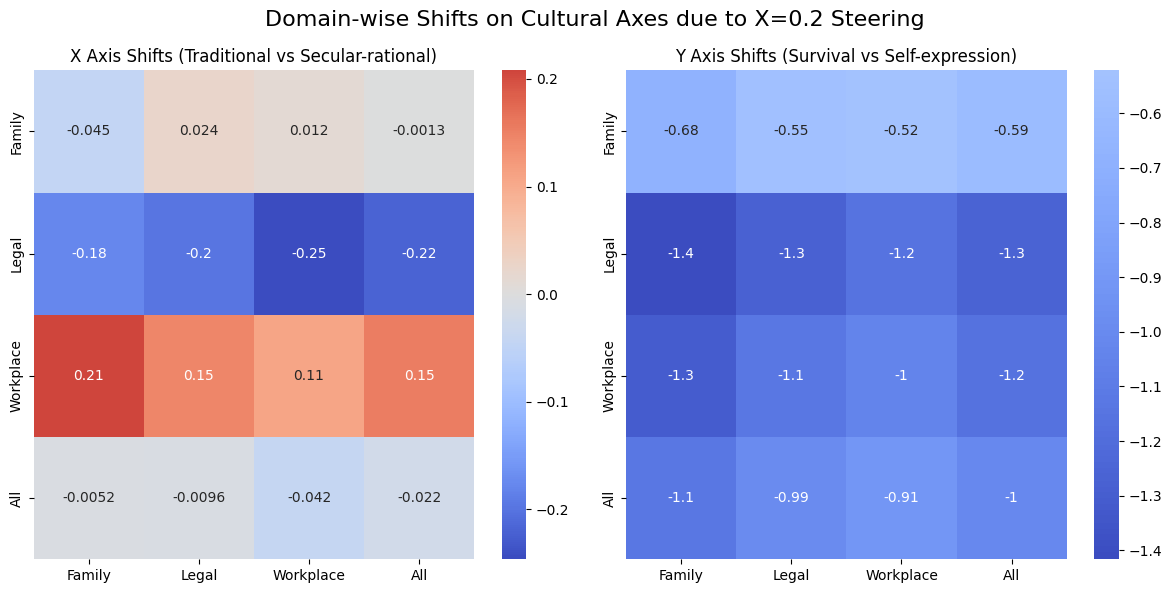

In [5]:
family_domain = load_probing_profile_data('../qwen_steering_outputs_4/results_Family_X_0.2.json', model_name="X=0.2", split_by_domain=True)
legal_domain = load_probing_profile_data('../qwen_steering_outputs_4/results_Legal_X_0.2.json', model_name="X=0.2", split_by_domain=True)
work_domain = load_probing_profile_data('../qwen_steering_outputs_4/results_Workplace_X_0.2.json', model_name="X=0.2", split_by_domain=True)
combine_domain = load_probing_profile_data('../qwen_steering_outputs_4/results_All_X_0.2.json', model_name="X=0.2", split_by_domain=True)

default_profile = load_probing_profile_data('../qwen_prompt_steer_outputs_4/evaluation_results_default.json', model_name="Default", split_by_domain=True)
default_profile.set_index('domain', inplace=True)

X_qwen = pd.DataFrame()
Y_qwen = pd.DataFrame()
name = ['Family', 'Legal', 'Workplace', 'All']
# select X columns only and stack 4 datafrmes and rename domain column to Method
for i, df in enumerate([family_domain, legal_domain, work_domain, combine_domain]):
	df.set_index('domain', inplace=True)
	#get domain by variable name
	X_qwen = pd.concat([X_qwen, (df['RC1']-default_profile['RC1']).rename(name[i])], axis=1)
	Y_qwen = pd.concat([Y_qwen, (df['RC2']-default_profile['RC2']).rename(name[i])], axis=1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

sns.heatmap(X_qwen, annot=True, cmap='coolwarm', center=0, ax=ax1)
ax1.set_title('X Axis Shifts (Traditional vs Secular-rational)')
sns.heatmap(Y_qwen, annot=True, cmap='coolwarm', center=0, ax=ax2)
ax2.set_title('Y Axis Shifts (Survival vs Self-expression)')
plt.suptitle('Domain-wise Shifts on Cultural Axes due to X=0.2 Steering', fontsize=16)
plt.tight_layout()
plt.show()

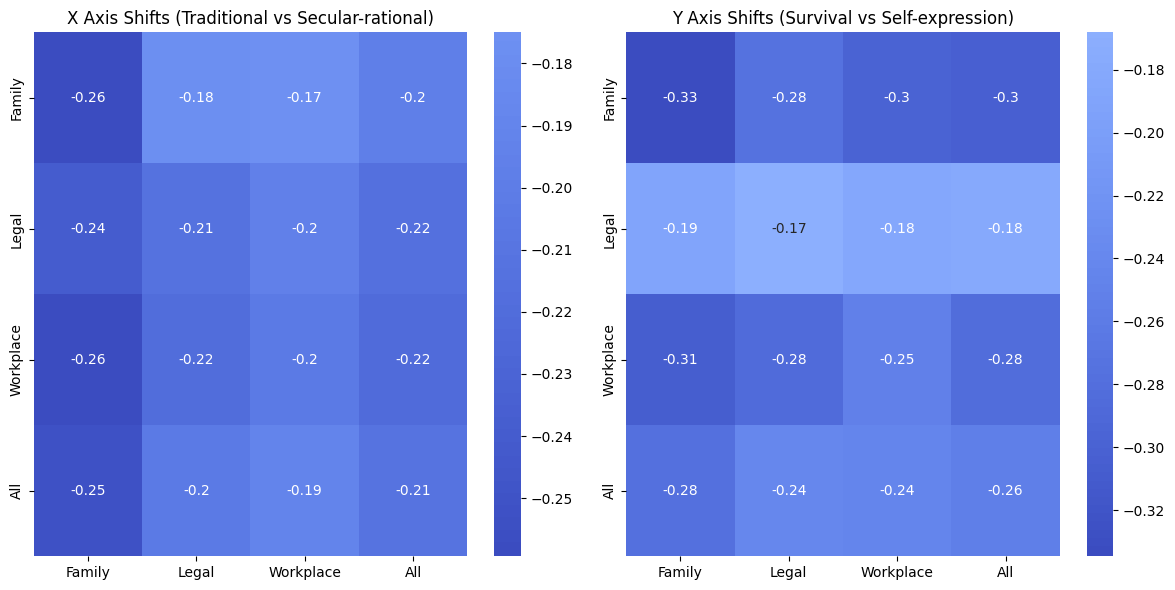

In [6]:
family_domain = load_probing_profile_data('../llama_steering_outputs/results_Family_X_0.2.json', model_name="X=0.2", split_by_domain=True)
legal_domain = load_probing_profile_data('../llama_steering_outputs/results_Legal_X_0.2.json', model_name="X=0.2", split_by_domain=True)
work_domain = load_probing_profile_data('../llama_steering_outputs/results_Workplace_X_0.2.json', model_name="X=0.2", split_by_domain=True)
combine_domain = load_probing_profile_data('../llama_steering_outputs/results_All_X_0.2.json', model_name="X=0.2", split_by_domain=True)

default_profile = load_probing_profile_data('../llama_prompt_steer_outputs/evaluation_results_default.json', model_name="Default", split_by_domain=True)
default_profile.set_index('domain', inplace=True)

X_llama = pd.DataFrame()
Y_llama = pd.DataFrame()
name = ['Family', 'Legal', 'Workplace', 'All']
# select X columns only and stack 4 datafrmes and rename domain column to Method
for i, df in enumerate([family_domain, legal_domain, work_domain, combine_domain]):
	df.set_index('domain', inplace=True)
	#get domain by variable name
	X_llama = pd.concat([X_llama, (df['RC1']-default_profile['RC1']).rename(name[i])], axis=1)
	Y_llama = pd.concat([Y_llama, (df['RC2']-default_profile['RC2']).rename(name[i])], axis=1)

 	# X_llama = pd.concat([X_llama, (df['X']-default_profile['X']).rename(name[i])], axis=1)
	# Y_llama = pd.concat([Y_llama, (df['Y']-default_profile['Y']).rename(name[i])], axis=1)
# plot 2 heatmaps side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
sns.heatmap(X_llama, annot=True, cmap='coolwarm', center=0, ax=ax1)
ax1.set_title('X Axis Shifts (Traditional vs Secular-rational)')
sns.heatmap(Y_llama, annot=True, cmap='coolwarm', center=0, ax=ax2)
ax2.set_title('Y Axis Shifts (Survival vs Self-expression)')
plt.tight_layout()
plt.show()

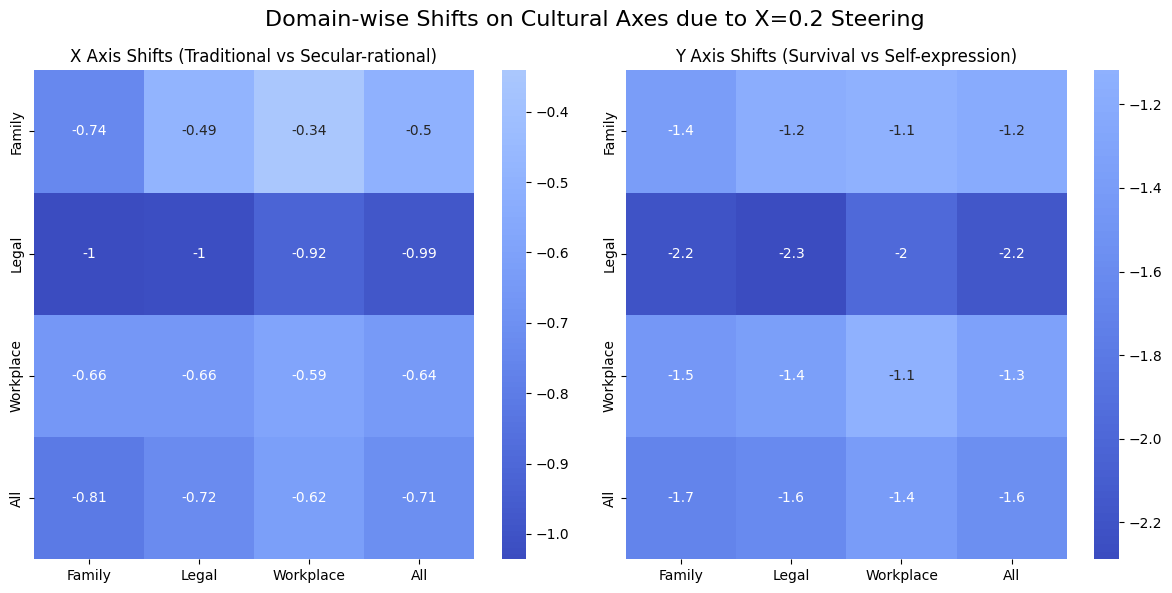

In [7]:
family_domain = load_probing_profile_data('../gemma_steering_outputs/results_Family_X_0.2.json', model_name="X=0.2", split_by_domain=True)
legal_domain = load_probing_profile_data('../gemma_steering_outputs/results_Legal_X_0.2.json', model_name="X=0.2", split_by_domain=True)
work_domain = load_probing_profile_data('../gemma_steering_outputs/results_Workplace_X_0.2.json', model_name="X=0.2", split_by_domain=True)
combine_domain = load_probing_profile_data('../gemma_steering_outputs/results_All_X_0.2.json', model_name="X=0.2", split_by_domain=True)

default_profile = load_probing_profile_data('../gemma_prompt_steer_outputs/evaluation_results_default.json', model_name="Default", split_by_domain=True)
default_profile.set_index('domain', inplace=True)

X_gemma = pd.DataFrame()
Y_gemma = pd.DataFrame()
name = ['Family', 'Legal', 'Workplace', 'All']
# select X columns only and stack 4 datafrmes and rename domain column to Method
for i, df in enumerate([family_domain, legal_domain, work_domain, combine_domain]):
	df.set_index('domain', inplace=True)
	#get domain by variable name
	X_gemma = pd.concat([X_gemma, (df['RC1']-default_profile['RC1']).rename(name[i])], axis=1)
	Y_gemma = pd.concat([Y_gemma, (df['RC2']-default_profile['RC2']).rename(name[i])], axis=1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

sns.heatmap(X_gemma, annot=True, cmap='coolwarm', center=0, ax=ax1)
ax1.set_title('X Axis Shifts (Traditional vs Secular-rational)')
sns.heatmap(Y_gemma, annot=True, cmap='coolwarm', center=0, ax=ax2)
ax2.set_title('Y Axis Shifts (Survival vs Self-expression)')
plt.suptitle('Domain-wise Shifts on Cultural Axes due to X=0.2 Steering', fontsize=16)
plt.tight_layout()
plt.show()

## Combined heatmaps across all three models


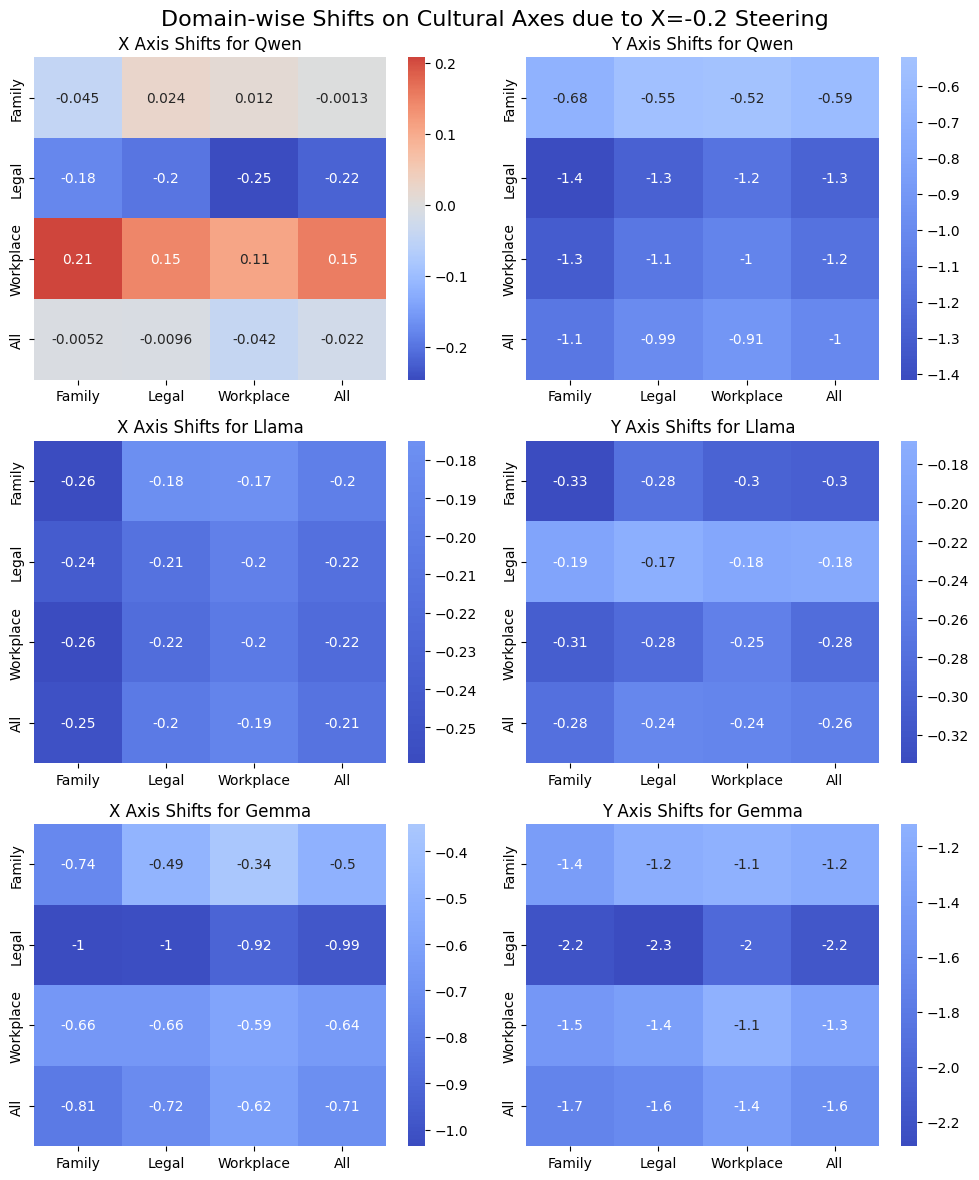

In [8]:
fig, axs = plt.subplots(3, 2, figsize=(10, 12))
sns.heatmap(X_qwen, annot=True, cmap='coolwarm', center=0, ax=axs[0, 0])
axs[0, 0].set_title('X Axis Shifts for Qwen')
sns.heatmap(Y_qwen, annot=True, cmap='coolwarm', center=0, ax=axs[0, 1])
axs[0, 1].set_title('Y Axis Shifts for Qwen')
sns.heatmap(X_llama, annot=True, cmap='coolwarm', center=0, ax=axs[1, 0])
axs[1, 0].set_title('X Axis Shifts for Llama')
sns.heatmap(Y_llama, annot=True, cmap='coolwarm', center=0, ax=axs[1, 1])
axs[1, 1].set_title('Y Axis Shifts for Llama')

sns.heatmap(X_gemma, annot=True, cmap='coolwarm', center=0, ax=axs[2, 0])
axs[2, 0].set_title('X Axis Shifts for Gemma')
sns.heatmap(Y_gemma, annot=True, cmap='coolwarm', center=0, ax=axs[2, 1])
axs[2, 1].set_title('Y Axis Shifts for Gemma')	

plt.suptitle('Domain-wise Shifts on Cultural Axes due to X=-0.2 Steering', fontsize=16)
plt.tight_layout()
plt.show()

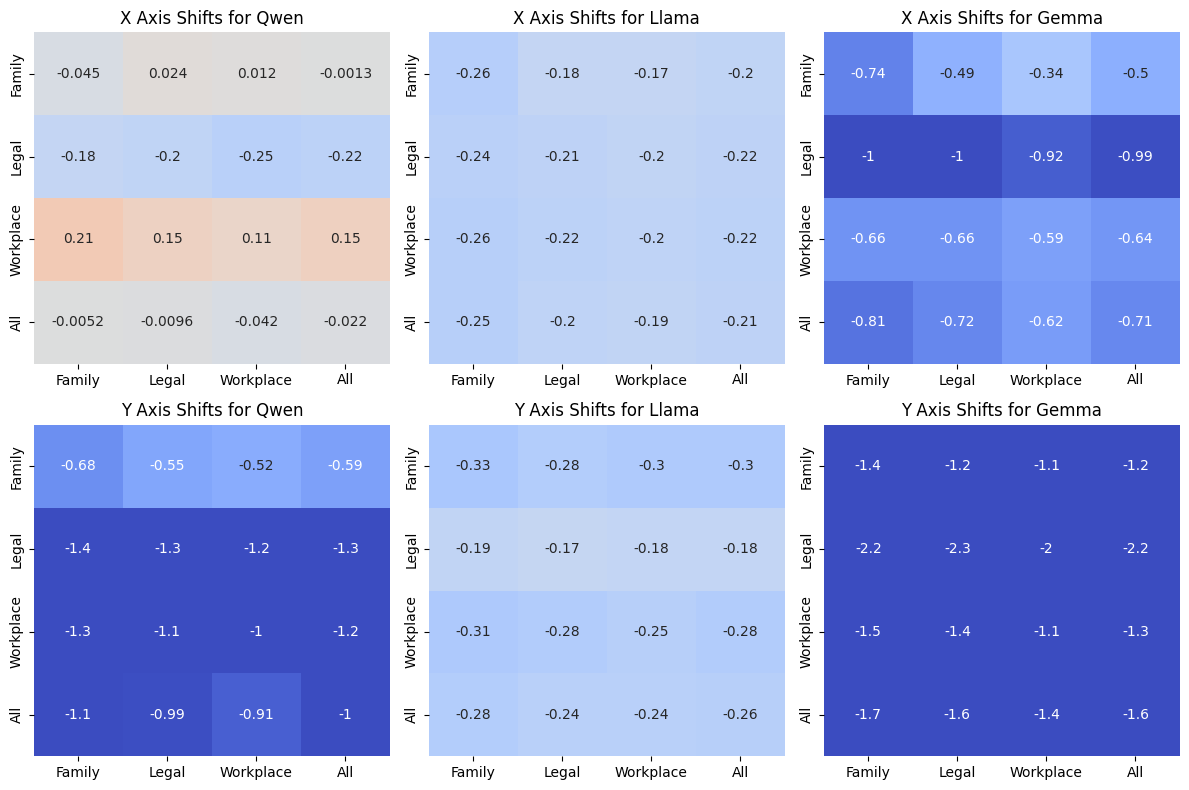

In [9]:
fig, axs = plt.subplots(2, 3, figsize=(12, 8))
vmin = -1
vmax = 1
# add norm color for every heatmap with center at 0 and same color range for all heatmaps
sns.heatmap(X_qwen, annot=True, cmap='coolwarm', center=0, ax=axs[0, 0], cbar=False, vmin=vmin, vmax=vmax)
axs[0, 0].set_title('X Axis Shifts for Qwen')
sns.heatmap(Y_qwen, annot=True, cmap='coolwarm', center=0, ax=axs[1, 0], cbar=False, vmin=vmin, vmax=vmax)
axs[1, 0].set_title('Y Axis Shifts for Qwen')
sns.heatmap(X_llama, annot=True, cmap='coolwarm', center=0, ax=axs[0, 1], cbar=False, vmin=vmin, vmax=vmax)
axs[0, 1].set_title('X Axis Shifts for Llama')
sns.heatmap(Y_llama, annot=True, cmap='coolwarm', center=0, ax=axs[1, 1], cbar=False, vmin=vmin, vmax=vmax)
axs[1, 1].set_title('Y Axis Shifts for Llama')

sns.heatmap(X_gemma, annot=True, cmap='coolwarm', center=0, ax=axs[0, 2], cbar=False, vmin=vmin, vmax=vmax)
axs[0, 2].set_title('X Axis Shifts for Gemma')
sns.heatmap(Y_gemma, annot=True, cmap='coolwarm', center=0, ax=axs[1, 2], cbar=False, vmin=vmin, vmax=vmax)
axs[1, 2].set_title('Y Axis Shifts for Gemma')	

# plt.suptitle('Domain-wise Shifts on Cultural Axes due to X=-0.2 Steering', fontsize=12)
plt.tight_layout()
plt.show()

In [18]:
#save to csv file
import os
os.makedirs('../outputs/domain_analysis_vector', exist_ok=True)
X_qwen.to_csv('../outputs/domain_analysis_vector/X_qwen.csv', sep='\t')
Y_qwen.to_csv('../outputs/domain_analysis_vector/Y_qwen.csv', sep='\t')
X_llama.to_csv('../outputs/domain_analysis_vector/X_llama.csv', sep='\t')
Y_llama.to_csv('../outputs/domain_analysis_vector/Y_llama.csv', sep='\t')
X_gemma.to_csv('../outputs/domain_analysis_vector/X_gemma.csv', sep='\t')
Y_gemma.to_csv('../outputs/domain_analysis_vector/Y_gemma.csv', sep='\t')

## Entanglement ratios over the grid-coefficient sweep


In [10]:
import re

def load_grid_coeff_data(grid_dir, model_label):
	"""Load and parse outputs_grid_coeff summary_results.json for one model."""
	with open(f"{grid_dir}/summary_results.json") as f:
		summary = json.load(f)
	rows = []
	for pt in summary["points"]:
		label = pt["label"]
		if label == "Baseline":
			rows.append({"model": model_label, "axis": "Baseline", 'begin_point': model_label,
						 "coeff": 0.0, "RC1": pt["RC1"], "RC2": pt["RC2"],'source_file': f"{grid_dir}/details/baseline.json"})
		else:
			m = re.match(r"vector_steering_([-.\d]+)_([XY])", label)
			file_path = f"{grid_dir}/details/{label}_{pt['country']}.json"
			if m:
				coeff, axis = float(m.group(1)), m.group(2)
				rows.append({"model": model_label, "axis": axis, "begin_point": model_label,
							 "coeff": coeff, "RC1": pt["RC1"], "RC2": pt["RC2"],'source_file': file_path})
	return pd.DataFrame(rows)


In [11]:
GRID_DIR = "../outputs_grid_coeff"
model_configs = [
    ("Qwen_Qwen3-4B-Instruct-2507",      "Qwen3-4B-Instruct"),
    ("google_gemma-3-4b-it",              "Gemma3-4B-it"),
    ("meta-llama_Llama-3.2-3B-Instruct", "Llama3.2-3B-Instruct"),
]

grid_df = pd.concat([
    load_grid_coeff_data(f"{GRID_DIR}/{d}", label)
    for d, label in model_configs
], ignore_index=True)

# probing_points_df

entanglement_df = add_entanglement_ratios(probing_points_df, grid_df)
entanglement_df = entanglement_df[entanglement_df['coeff']>0]


# 1. Define the columns to be processed
cols = [
    'Entanglement_Ratio_All', 
    'Entanglement_Ratio_Family', 
    'Entanglement_Ratio_Legal', 
    'Entanglement_Ratio_Workplace'
]

# 2. Group by begin_point and calculate mean and std for all columns
stats = entanglement_df.groupby('begin_point')[cols].agg(['mean', 'std'])

# 3. Create a new DataFrame to store the formatted strings
formatted_df = pd.DataFrame(index=stats.index)

for col in cols:
    # We use a lambda to format each row. 
    # Added a check for NaN in case a group has only 1 observation.
    formatted_df[col] = stats[col].apply(
        lambda x: f"{x['mean']:.3f} ± {x['std']:.3f}" if pd.notnull(x['std']) else f"{x['mean']:.3f}", 
        axis=1
    )

# Display the result
formatted_df

,Entanglement_Ratio_All,Entanglement_Ratio_Family,Entanglement_Ratio_Legal,Entanglement_Ratio_Workplace
begin_point,,,,
Gemma3-4B-it,0.768 ± 0.097,0.561 ± 0.073,0.773 ± 0.101,0.875 ± 0.064
Llama3.2-3B-Instruct,0.720 ± 0.069,0.553 ± 0.117,0.515 ± 0.143,0.805 ± 0.089
Qwen3-4B-Instruct,0.814 ± 0.139,0.831 ± 0.137,0.793 ± 0.196,0.729 ± 0.152


## Entanglement ratios over best-coeff binary-search results


In [12]:
def load_model_binary_search(binary_search_dir, base_model, color="cyan"):
    """Load best-coeff results from an outputs_binary_search/<model> directory.
    Reads summary_results.json to find the best-coeff file per country.
    """
    import json, os
    summary_path = os.path.join(binary_search_dir, "summary_results.json")
    with open(summary_path) as f:
        summary = json.load(f)

    vector_df = pd.DataFrame()
    for v in summary["vectors"]:
        if not v.get("is_best_coeff"):
            continue
        # label: "vector_Denmark_vec_x_0.148... (best_grid)" -> file: "vector_Denmark_vec_x_0.148..._mlt.json"
        label = v["label"].replace(" (best_grid)", "")
        filename = label + "_mlt.json"
        file_path = os.path.join(binary_search_dir, "details", filename)
        country = label.split("_")[1]  # "vector_{country}_vec_x_..." -> country name
        tmp = load_probing_profile_data(file_path, model_name=f"to {country}")
        tmp["color"] = 'green' if 'advance' in label else 'brown'
        tmp['coeff'] = round(float(label.split("_")[-1]), 2)
        tmp['source_file'] = file_path
        vector_df = pd.concat([vector_df, tmp], ignore_index=True)

    vector_df["begin_point"] = base_model
    return vector_df

# Load binary search best-coeff results for each model
probing_qwen_binary_df  = load_model_binary_search("../outputs_binary_search/Qwen_Qwen3-4B-Instruct-2507",       "Qwen3-4B-Instruct",    color="cyan")
probing_gemma_binary_df = load_model_binary_search("../outputs_binary_search/google_gemma-3-4b-it",             "Gemma3-4B-it",         color="cyan")
probing_llama_binary_df = load_model_binary_search("../outputs_binary_search/meta-llama_Llama-3.2-3B-Instruct", "Llama3.2-3B-Instruct", color="cyan")


In [13]:
import pandas as pd
tmp = add_entanglement_ratios(probing_points_df, pd.concat([probing_qwen_binary_df, probing_llama_binary_df, probing_gemma_binary_df], ignore_index=True))

# 1. Define the columns to be processed
cols = [
    'Entanglement_Ratio_All', 
    'Entanglement_Ratio_Family', 
    'Entanglement_Ratio_Legal', 
    'Entanglement_Ratio_Workplace'
]

# 2. Group by begin_point and calculate mean and std for all columns
stats = tmp.groupby('begin_point')[cols].agg(['mean', 'std'])

# 3. Create a new DataFrame to store the formatted strings
formatted_df = pd.DataFrame(index=stats.index)

for col in cols:
    # We use a lambda to format each row. 
    # Added a check for NaN in case a group has only 1 observation.
    formatted_df[col] = stats[col].apply(
        lambda x: f"{x['mean']:.3f} ± {x['std']:.3f}" if pd.notnull(x['std']) else f"{x['mean']:.3f}", 
        axis=1
    )

# Display the result
formatted_df

,Entanglement_Ratio_All,Entanglement_Ratio_Family,Entanglement_Ratio_Legal,Entanglement_Ratio_Workplace
begin_point,,,,
Gemma3-4B-it,0.734 ± 0.072,0.588 ± 0.125,0.668 ± 0.131,0.885 ± 0.139
Llama3.2-3B-Instruct,0.531 ± 0.194,0.466 ± 0.125,0.358 ± 0.126,0.830 ± 0.227
Qwen3-4B-Instruct,0.737 ± 0.032,0.719 ± 0.068,0.708 ± 0.054,0.798 ± 0.074


# Domain-analysis-specific for best-coeff binary-search results

In [14]:
import os
from ultis import pca_result_country_level

default_files = {
	"Qwen3-4B-Instruct":    '../qwen_prompt_steer_outputs_4/evaluation_results_default.json',
	"Llama3.2-3B-Instruct": '../llama_prompt_steer_outputs/evaluation_results_default.json',
	"Gemma3-4B-it":         '../gemma_prompt_steer_outputs/evaluation_results_default.json',
}

binary_dfs = {
	"Qwen3-4B-Instruct":    probing_qwen_binary_df,
	"Llama3.2-3B-Instruct": probing_llama_binary_df,
	"Gemma3-4B-it":         probing_gemma_binary_df,
}

domain_order  = ['Family', 'Legal', 'Workplace', 'All']
country_order = ['Denmark', 'Vietnam', 'India', 'Mexico']

# Target country coords on the cultural map (human WVS/EVS country means)
country_coords = (
	pca_result_country_level
	.set_index('country.territory')[['RC1_final', 'RC2_final']]
	.to_dict('index')
)

# Per-model base point (overall) — from probing_points_df
base_points = probing_points_df.set_index('country')[['RC1', 'RC2']].to_dict('index')

def domain_shift_tables(model_name, df, normalize=True):
	"""Return (X_shift, Y_shift) DataFrames: rows=domain, cols=target country.
	Uses only rows with color == 'brown' (advanced-prompt best-coeff).
	If normalize, each column is divided by the per-axis gap (target - base);
	1.0 means the shift exactly closed the gap on that axis."""
	green = df[df['color'] == 'brown'].copy()
	green['target_country'] = green['source_file'].apply(
		lambda p: os.path.basename(p).split('_')[1]
	)
	default_profile = load_probing_profile_data(
		default_files[model_name], model_name="Default", split_by_domain=True
	).set_index('domain')

	base = base_points[model_name]

	X_shift = pd.DataFrame(index=domain_order, columns=country_order, dtype=float)
	Y_shift = pd.DataFrame(index=domain_order, columns=country_order, dtype=float)

	for _, row in green.iterrows():
		country = row['target_country']
		if country not in country_order:
			continue
		prof = load_probing_profile_data(
			row['source_file'], model_name=country, split_by_domain=True
		).set_index('domain')
		for d in domain_order:
			if d in prof.index and d in default_profile.index:
				X_shift.loc[d, country] = prof.loc[d, 'RC1'] - default_profile.loc[d, 'RC1']
				Y_shift.loc[d, country] = prof.loc[d, 'RC2'] - default_profile.loc[d, 'RC2']

	if normalize:
		for c in country_order:
			tgt = country_coords.get(c)
			if tgt is None:
				continue
			gap_x = tgt['RC1_final'] - base['RC1']
			gap_y = tgt['RC2_final'] - base['RC2']
			if gap_x != 0:
				X_shift[c] = X_shift[c] / gap_x
			if gap_y != 0:
				Y_shift[c] = Y_shift[c] / gap_y

	return X_shift.astype(float), Y_shift.astype(float)

shift_tables = {m: domain_shift_tables(m, df) for m, df in binary_dfs.items()}
shift_tables["Qwen3-4B-Instruct"][0]


,Denmark,Vietnam,India,Mexico
Family,0.410296,0.867926,0.754799,0.899619
Legal,0.402024,1.101678,0.851687,1.161072
Workplace,0.873537,0.867891,0.694684,0.751385
All,0.561952,0.945832,0.767056,0.937359


In [15]:
shift_tables

{'Qwen3-4B-Instruct': (            Denmark   Vietnam     India    Mexico
  Family     0.410296  0.867926  0.754799  0.899619
  Legal      0.402024  1.101678  0.851687  1.161072
  Workplace  0.873537  0.867891  0.694684  0.751385
  All        0.561952  0.945832  0.767056  0.937359,
              Denmark   Vietnam     India    Mexico
  Family     0.774226  1.024019  1.035786  0.800301
  Legal      0.957194  1.154745  1.055795  0.807972
  Workplace  0.840600  1.159004  1.164528  0.886254
  All        0.857340  1.112589  1.085369  0.831509),
 'Llama3.2-3B-Instruct': (            Denmark   Vietnam     India    Mexico
  Family     0.160229  0.428700  0.302806  0.465734
  Legal      0.192229  0.189463  0.160021  0.273630
  Workplace  0.351039  0.194617  0.183624  0.259842
  All        0.234499  0.270927  0.215484  0.333069,
              Denmark   Vietnam     India    Mexico
  Family     0.478569  0.526890  0.381555  0.261586
  Legal      0.022562  0.351395  0.176667  0.126383
  Workplace  0.

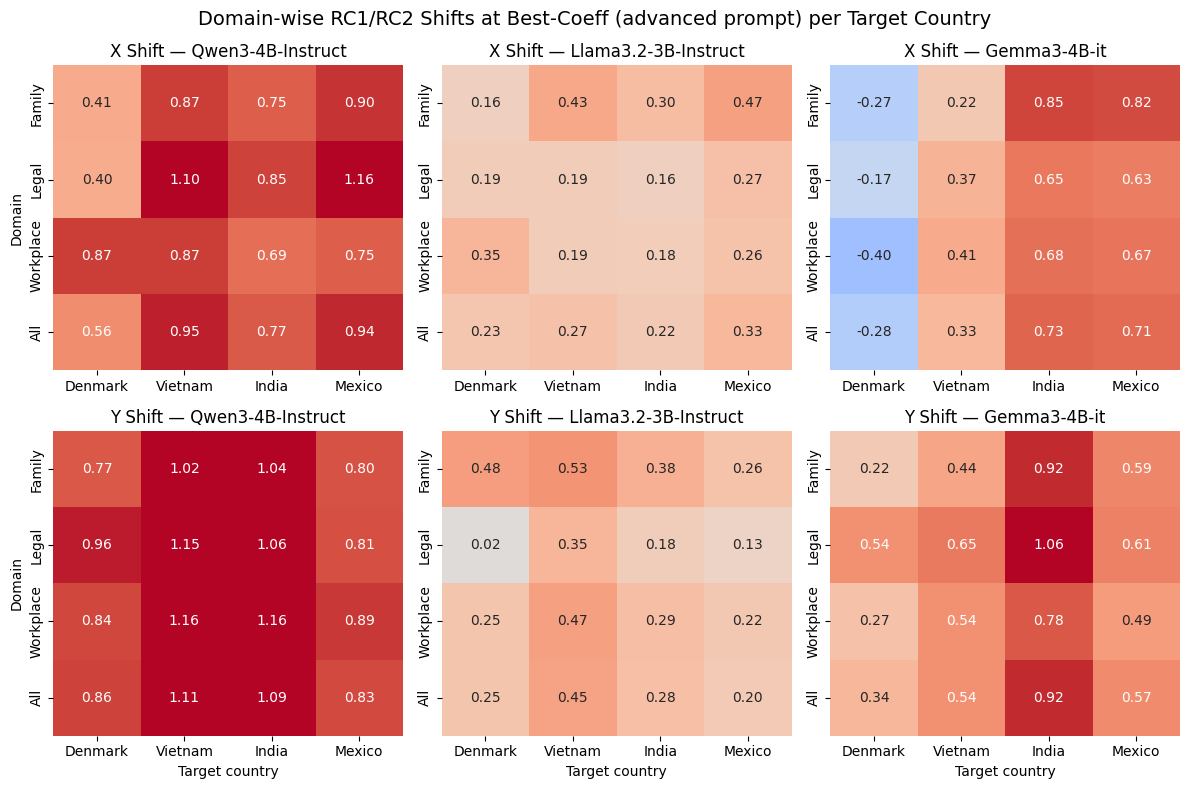

In [16]:
fig, axs = plt.subplots(2, 3, figsize=(12, 8))
vmin, vmax = -1, 1

for col_idx, (model_name, (X_shift, Y_shift)) in enumerate(shift_tables.items()):
    sns.heatmap(X_shift, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                ax=axs[0, col_idx], cbar=False, vmin=vmin, vmax=vmax)
    axs[0, col_idx].set_title(f'X Shift — {model_name}')
    axs[0, col_idx].set_xlabel('')
    axs[0, col_idx].set_ylabel('Domain' if col_idx == 0 else '')

    sns.heatmap(Y_shift, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                ax=axs[1, col_idx], cbar=False, vmin=vmin, vmax=vmax)
    axs[1, col_idx].set_title(f'Y Shift — {model_name}')
    axs[1, col_idx].set_xlabel('Target country')
    axs[1, col_idx].set_ylabel('Domain' if col_idx == 0 else '')

plt.suptitle('Domain-wise RC1/RC2 Shifts at Best-Coeff (advanced prompt) per Target Country',
             fontsize=14)
plt.tight_layout()
plt.show()

In [21]:
# save to csv file
import os
os.makedirs('../outputs/domain_analysis_hybrid', exist_ok=True)
for model_name, (X_shift, Y_shift) in shift_tables.items():
	print(X_shift)
	X_shift.to_csv(f'../outputs/domain_analysis_hybrid/{model_name}_X_shift.csv', sep='\t')
	Y_shift.to_csv(f'../outputs/domain_analysis_hybrid/{model_name}_Y_shift.csv', sep='\t')

            Denmark   Vietnam     India    Mexico
Family     0.410296  0.867926  0.754799  0.899619
Legal      0.402024  1.101678  0.851687  1.161072
Workplace  0.873537  0.867891  0.694684  0.751385
All        0.561952  0.945832  0.767056  0.937359
            Denmark   Vietnam     India    Mexico
Family     0.160229  0.428700  0.302806  0.465734
Legal      0.192229  0.189463  0.160021  0.273630
Workplace  0.351039  0.194617  0.183624  0.259842
All        0.234499  0.270927  0.215484  0.333069
            Denmark   Vietnam     India    Mexico
Family    -0.265620  0.223571  0.850940  0.823224
Legal     -0.171562  0.365232  0.652748  0.632060
Workplace -0.396990  0.412299  0.683280  0.667589
All       -0.278057  0.333701  0.728989  0.707624
